Using pipeline file: C:\Users\pkwki\project_nextgen\pipelinefinalproject.py

easy: data4d (32, 32, 96, 96) GT frac=0.153
Clustering 1024 patterns into 2 clusters using gmm with features ['radial', 'detectors', 'angular', 'bragginess']
PCA: kept 12 components for 98.0% variance target
Mapping: precip=(label==0) | mapping-acc: 1.0
Metrics: {'precision': 0.9999999999999937, 'recall': 0.9999999999999937, 'f1': 0.9999999999994937, 'iou': 0.9999999999999937, 'accuracy': 0.9999999999999991, 'TP': 157, 'FP': 0, 'FN': 0}


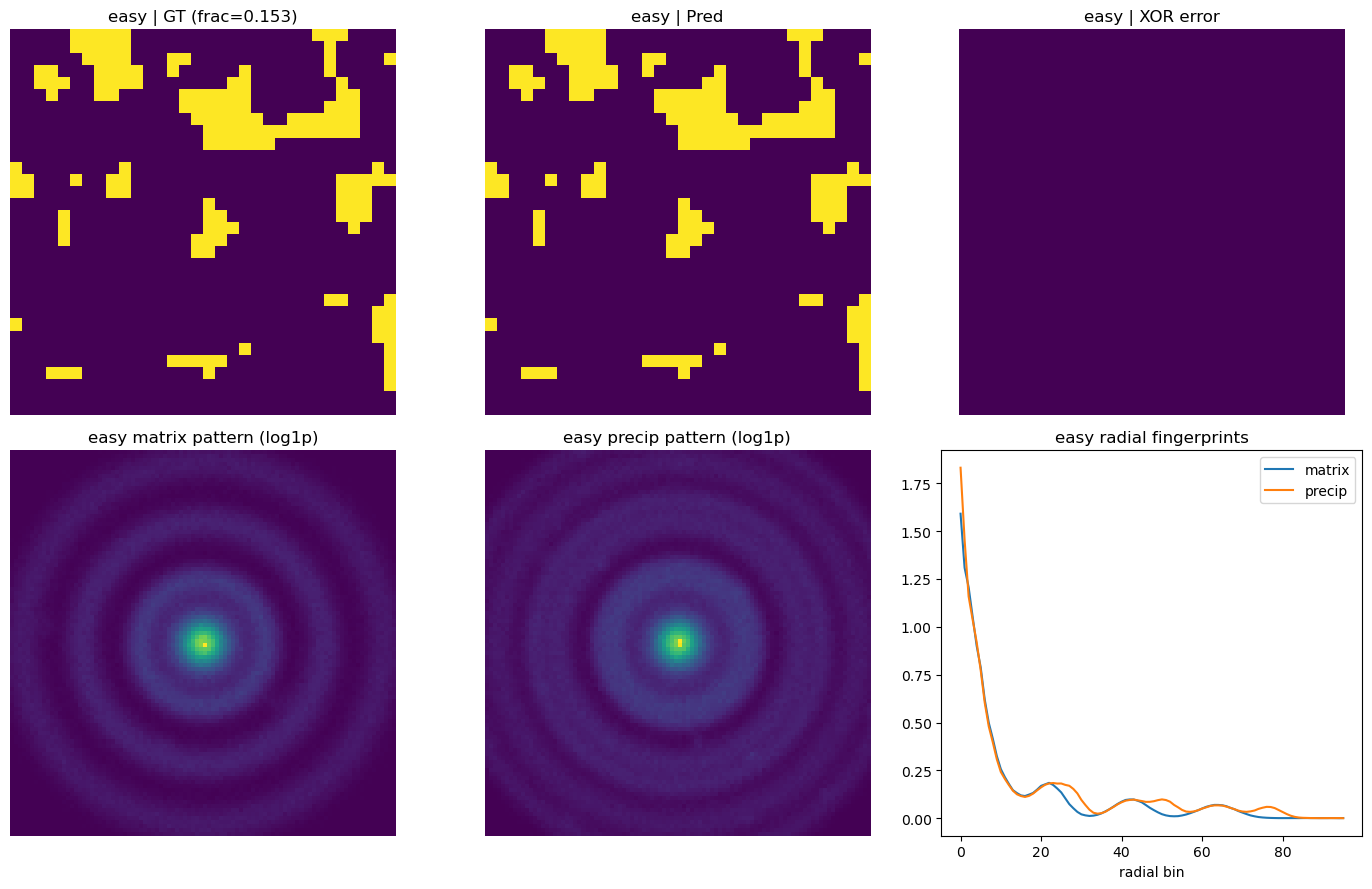


medium: data4d (32, 32, 96, 96) GT frac=0.102
Clustering 1024 patterns into 2 clusters using gmm with features ['radial', 'detectors', 'angular', 'bragginess']
PCA: kept 13 components for 98.0% variance target
Mapping: precip=(label==0) | mapping-acc: 0.9189453125
Metrics: {'precision': 0.9999999999999525, 'recall': 0.20192307692307498, 'f1': 0.3359999999997151, 'iou': 0.20192307692307498, 'accuracy': 0.9189453124999992, 'TP': 21, 'FP': 0, 'FN': 83}


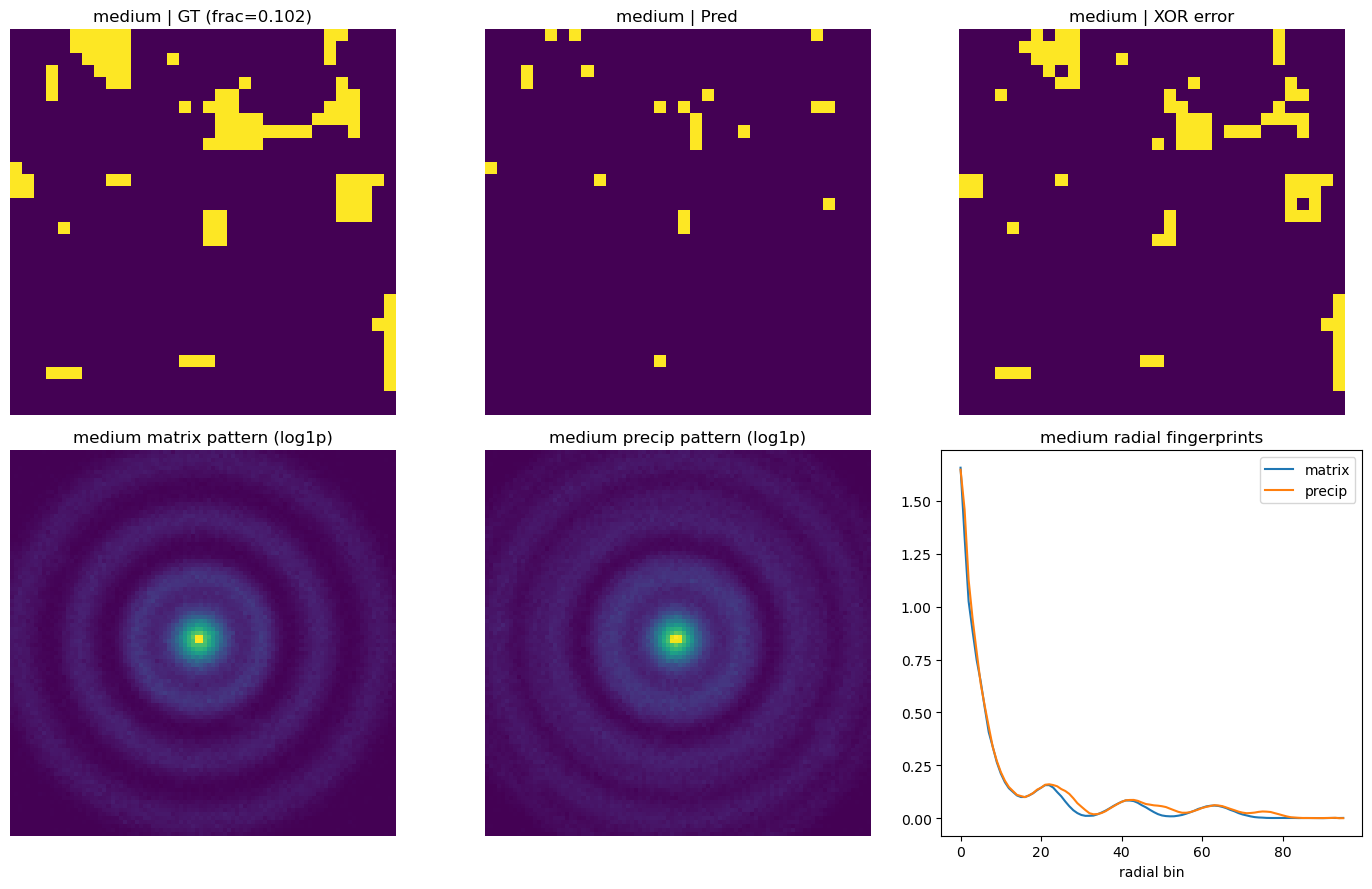


hard: data4d (32, 32, 96, 96) GT frac=0.051
Clustering 1024 patterns into 2 clusters using gmm with features ['radial', 'detectors', 'angular', 'bragginess']
PCA: kept 18 components for 98.0% variance target
Mapping: precip=(label==0) | mapping-acc: 0.73828125
Metrics: {'precision': 0.07480314960629891, 'recall': 0.36538461538460837, 'f1': 0.12418300653566479, 'iou': 0.06620209059233426, 'accuracy': 0.7382812499999993, 'TP': 19, 'FP': 235, 'FN': 33}


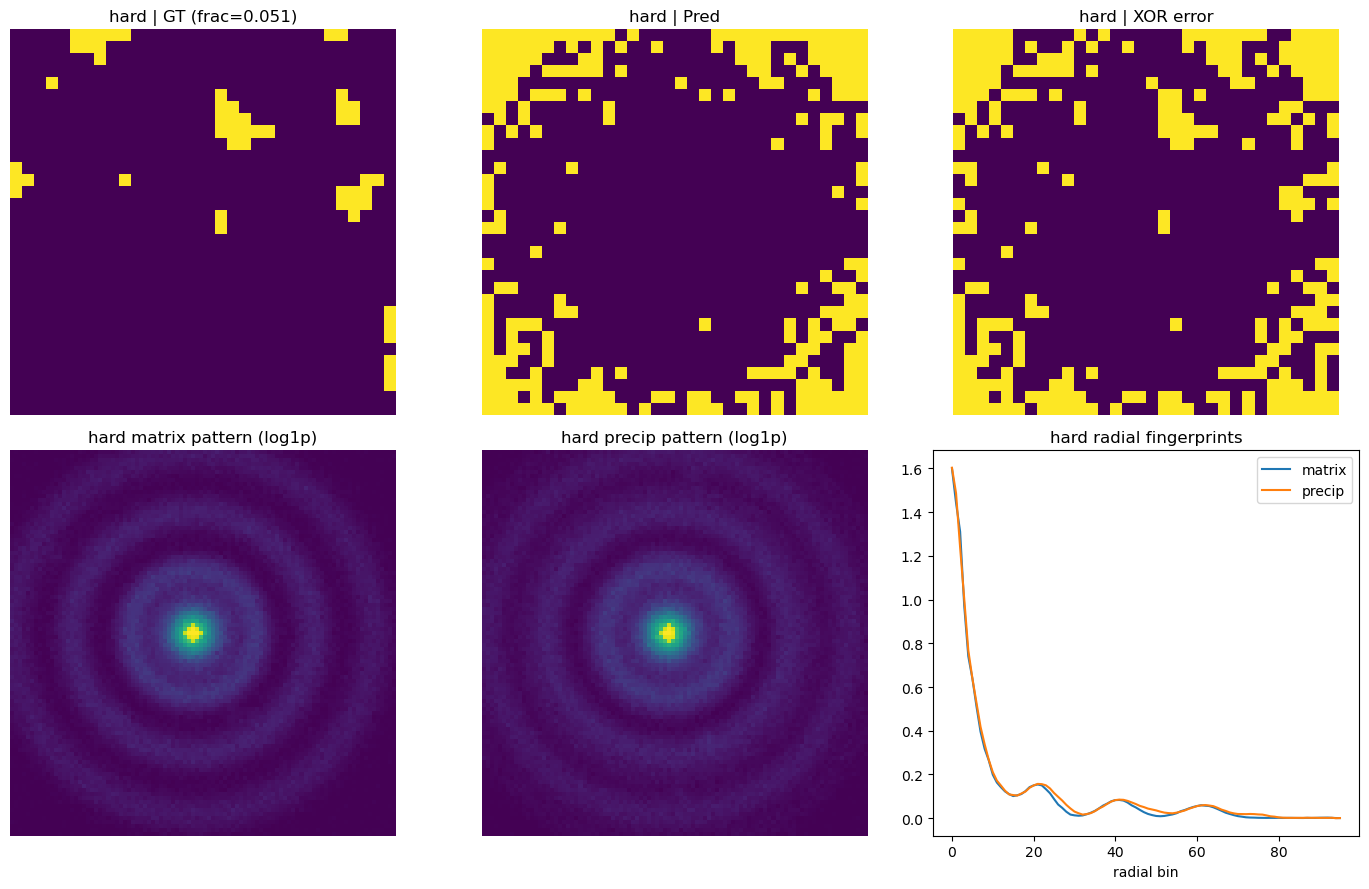


=== SUMMARY TABLE (higher is better; watch FN/FP) ===
  easy | 0.153 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 |  157 |   0 |   0 | precip=(label==0)
medium | 0.102 | 1.000 | 0.202 | 0.336 | 0.202 | 0.919 |   21 |   0 |  83 | precip=(label==0)
  hard | 0.051 | 0.075 | 0.365 | 0.124 | 0.066 | 0.738 |   19 | 235 |  33 | precip=(label==0)


In [3]:
# ============================================
# Run EASY / MEDIUM / HARD simulations quickly
# ============================================
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 0) Load pipeline module
# -------------------------
import pipelinefinalproject as pf
print("Using pipeline file:", pf.__file__)

# -------------------------
# 1) Metrics helper
# -------------------------
def metrics_binary(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    TP = np.logical_and(pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    acc = (TP + TN) / (TP + TN + FP + FN + 1e-12)
    prec = TP / (TP + FP + 1e-12)
    rec = TP / (TP + FN + 1e-12)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    iou = TP / (TP + FP + FN + 1e-12)
    return dict(precision=float(prec), recall=float(rec), f1=float(f1), iou=float(iou),
                accuracy=float(acc), TP=int(TP), FP=int(FP), FN=int(FN))

def best_binary_mapping(pred01, gt_bool):
    A = pred01.astype(bool)      # precip = label==1
    B = ~A                       # precip = label==0
    accA = (A == gt_bool).mean()
    accB = (B == gt_bool).mean()
    if accB > accA:
        return B.astype(int), "precip=(label==0)", accB
    return A.astype(int), "precip=(label==1)", accA

# -------------------------
# 2) Plot helper (optional)
# -------------------------
def show_case_plots(name, data4d, gt, pred_precip):
    ny, nx, P, _ = data4d.shape

    # pick one precip and one matrix pixel
    if gt.any():
        yy_p, xx_p = np.argwhere(gt)[0]
    else:
        yy_p, xx_p = 0, 0
    yy_m, xx_m = np.argwhere(~gt)[0]

    pat_m = data4d[yy_m, xx_m]
    pat_p = data4d[yy_p, xx_p]

    # Use pipeline radial (preprocessed patterns ideally, but we keep simple)
    cy_m, cx_m = pf.estimate_center_of_mass(pat_m)
    cy_p, cx_p = pf.estimate_center_of_mass(pat_p)
    rp_m = pf.radial_profile(pat_m, center=(cy_m, cx_m), radial_bins=96)
    rp_p = pf.radial_profile(pat_p, center=(cy_p, cx_p), radial_bins=96)

    fig = plt.figure(figsize=(14, 9))
    ax = plt.subplot(2,3,1); ax.imshow(gt, interpolation="nearest"); ax.set_title(f"{name} | GT (frac={gt.mean():.3f})"); ax.axis("off")
    ax = plt.subplot(2,3,2); ax.imshow(pred_precip, interpolation="nearest"); ax.set_title(f"{name} | Pred"); ax.axis("off")
    ax = plt.subplot(2,3,3); ax.imshow(pred_precip ^ gt, interpolation="nearest"); ax.set_title(f"{name} | XOR error"); ax.axis("off")
    ax = plt.subplot(2,3,4); ax.imshow(np.log1p(pat_m), interpolation="nearest"); ax.set_title(f"{name} matrix pattern (log1p)"); ax.axis("off")
    ax = plt.subplot(2,3,5); ax.imshow(np.log1p(pat_p), interpolation="nearest"); ax.set_title(f"{name} precip pattern (log1p)"); ax.axis("off")
    ax = plt.subplot(2,3,6); ax.plot(rp_m, label="matrix"); ax.plot(rp_p, label="precip"); ax.set_title(f"{name} radial fingerprints"); ax.set_xlabel("radial bin"); ax.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# 3) Fixed pipeline settings
# -------------------------
pipe_kwargs_fixed = dict(
    n_clusters=2,
    method="gmm",            # important
    radial_bins=96,
    feature_groups=["radial", "detectors", "angular", "bragginess"],
    preprocess_kwargs=dict(
        blur_sigma=4.0,
        log_compress=True,
        winsor_q=0.999,
        center_mask_frac=0.04,
        normalize="max",      # important (NOT "sum")
    ),
    use_pca=True,
    pca_var=0.98,
    detrend=False,           # important for your sim
    map_precipitate=True,
    size_prior=0.2,          # encourage "precip is rare" (tune 0.1–0.3)
    spatial_refine=False,
    verbose=True,
)

# -------------------------
# 4) Define EASY / MEDIUM / HARD simulation knobs
# -------------------------
# NOTE: These are SIMULATION PARAMETERS (not pipeline parameters).
# Pick ONE simulator option below.

ny, nx, P = 32, 32, 96

cases = [
    ("easy",   dict(ny=ny, nx=nx, P=P, precipitate_fraction=0.15, contrast=0.60, noise_level=0.6,  drift_px=0.0, thickness_gradient=False, beamstop_frac=0.01, orient_variation=False)),
    ("medium", dict(ny=ny, nx=nx, P=P, precipitate_fraction=0.10, contrast=0.35, noise_level=1.0,  drift_px=2.0, thickness_gradient=True,  beamstop_frac=0.02, orient_variation=True)),
    ("hard",   dict(ny=ny, nx=nx, P=P, precipitate_fraction=0.05, contrast=0.20, noise_level=1.4,  drift_px=5.0, thickness_gradient=True,  beamstop_frac=0.03, orient_variation=True)),
]

# -------------------------
# 5) Choose your simulator
# -------------------------

# ===== OPTION A: Use YOUR notebook simulator (if you already have it) =====
# Make sure your function signature matches these keys:
# simulate_metal_4dstem_dataset(ny,nx,P,precipitate_fraction,contrast,drift_px,thickness_gradient,beamstop_frac,noise_level,orient_variation,seed=...)
USE_SIM = "A"

# ===== OPTION B: Use pf.simulate_4dstem_dataset (if that exists in your module) =====
# This is a fallback; may have fewer realism knobs.
# USE_SIM = "B"

# -------------------------
# 6) Run all cases
# -------------------------
results = []
SHOW_PLOTS = True   # set False to run faster

for ci, (name, sim_kwargs) in enumerate(cases):
    seed = 0
    sim_kwargs2 = dict(sim_kwargs)
    sim_kwargs2["seed"] = seed

    # --- simulate ---
    if USE_SIM == "A":
        data4d, gt = simulate_metal_4dstem_dataset(**sim_kwargs2)
    else:
        # fallback (limited knobs) — adjust if your pf.simulate signature differs
        data4d, gt = pf.simulate_4dstem_dataset(
            ny=sim_kwargs2["ny"], nx=sim_kwargs2["nx"],
            pattern_size=sim_kwargs2["P"],
            precipitate_fraction=sim_kwargs2["precipitate_fraction"],
            seed=seed
        )

    print(f"\n{name}: data4d {data4d.shape} GT frac={gt.mean():.3f}")

    # --- run pipeline ---
    res = pf.detect_phases_multi(data4d, **pipe_kwargs_fixed)

    # pipeline should return a 2D label map; if flattened, reshape:
    if "labels_map" in res:
        pred0 = res["labels_map"].astype(int)
    else:
        pred0 = res["labels"].reshape(sim_kwargs2["ny"], sim_kwargs2["nx"]).astype(int)

    # --- map cluster id -> precip mask (best mapping) ---
    pred_precip, mapping_note, mapping_acc = best_binary_mapping(pred0, gt)
    m = metrics_binary(pred_precip, gt)
    m.update(dict(case=name, gt_frac=float(gt.mean()), mapping=mapping_note, mapping_acc=float(mapping_acc)))
    results.append(m)

    print("Mapping:", mapping_note, "| mapping-acc:", mapping_acc)
    print("Metrics:", {k: m[k] for k in ["precision","recall","f1","iou","accuracy","TP","FP","FN"]})

    if SHOW_PLOTS:
        show_case_plots(name, data4d, gt, pred_precip.astype(bool))

# -------------------------
# 7) Summary table
# -------------------------
print("\n=== SUMMARY TABLE (higher is better; watch FN/FP) ===")
cols = ["case","gt_frac","precision","recall","f1","iou","accuracy","TP","FP","FN","mapping"]
for r in results:
    print(f"{r['case']:>6s} | {r['gt_frac']:.3f} | {r['precision']:.3f} | {r['recall']:.3f} | {r['f1']:.3f} | {r['iou']:.3f} | {r['accuracy']:.3f} | {r['TP']:4d} | {r['FP']:3d} | {r['FN']:3d} | {r['mapping']}")

These difficulty levels come from how much we bury the precipitate signal:

Contrast ↓ (rings/spots become less different from matrix)

Noise ↑ (Poisson + detector noise hides peaks)

Drift ↑ (center estimation/radial integration gets worse)

Thickness gradient on (adds systematic intensity variation across scan that can dominate clustering)

Beamstop fraction ↑ (removes the strongest central information, can hurt BF/DF and COM features)

Orientation variation on (angular features/bragginess become less consistent)

What the metrics mean

Recall: “Did I find the precipitate pixels?” (high recall = low FN)

Precision: “When I say precipitate, am I correct?” (high precision = low FP)

IoU: strict overlap measure (best single segmentation metric)

Accuracy can be misleading if precipitates are rare (you can get high accuracy by predicting all matrix).